In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
%matplotlib inline

# Enlace de almacenamiento oficial de IBM para el proyecto
filepath = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/FinalModule_Coursera/data/kc_house_data_NaN.csv'
df = pd.read_csv(filepath)
df.head()

,Unnamed: 0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,7129300520,20141013T000000,221900.0,3.0,1.00,1180,5650,1.0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,6414100192,20141209T000000,538000.0,3.0,2.25,2570,7242,2.0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2,5631500400,20150225T000000,180000.0,2.0,1.00,770,10000,1.0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,3,2487200875,20141209T000000,604000.0,4.0,3.00,1960,5000,1.0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,4,1954400510,20150218T000000,510000.0,3.0,2.00,1680,8080,1.0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [2]:
# Mostrar tipos de datos de cada columna
print(df.dtypes)

Unnamed: 0         int64
id                 int64
date              object
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object


In [3]:
# Eliminar columnas que no aportan al análisis y obtener el resumen estadístico
df.drop(["id", "Unnamed: 0"], axis=1, inplace=True)
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21600.000000,21603.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.372870,2.115736,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,3.671272e+05,0.926657,0.768996,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,7.500000e+04,1.000000,0.500000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [4]:
# Reemplazar valores nulos (NaN) con la media correspondiente
mean_bedrooms = df['bedrooms'].mean()
df['bedrooms'].replace(np.nan, mean_bedrooms, inplace=True)

mean_bathrooms = df['bathrooms'].mean()
df['bathrooms'].replace(np.nan, mean_bathrooms, inplace=True)

# Verificar que ya no queden nulos en esas columnas
print("Valores nulos en bedrooms:", df['bedrooms'].isnull().sum())
print("Valores nulos en bathrooms:", df['bathrooms'].isnull().sum())

Valores nulos en bedrooms: 0
Valores nulos en bathrooms: 0


/tmp/ipykernel_2367/2685881068.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bedrooms'].replace(np.nan, mean_bedrooms, inplace=True)
/tmp/ipykernel_2367/2685881068.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

In [5]:
# Obtener el conteo de pisos y convertirlo en DataFrame
floors_counts = df['floors'].value_counts().to_frame()
floors_counts

,count
floors,
1.0,10680
2.0,8241
1.5,1910
3.0,613
2.5,161
3.5,8


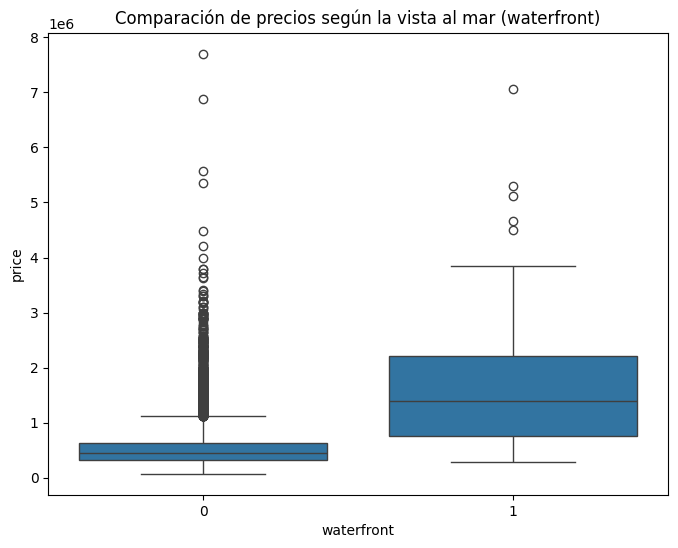

In [6]:
# Gráfico de caja para comparar precios con y sin vista al mar
plt.figure(figsize=(8, 6))
sns.boxplot(x="waterfront", y="price", data=df)
plt.title("Comparación de precios según la vista al mar (waterfront)")
plt.show()

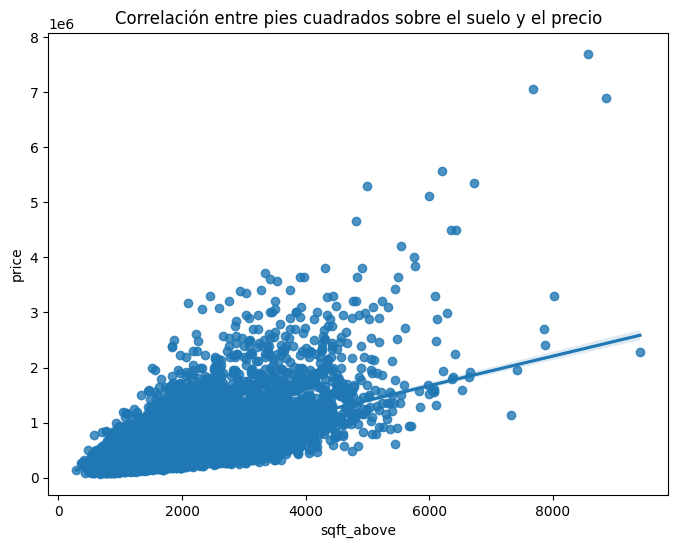

In [7]:
# Gráfico de regresión para analizar correlación
plt.figure(figsize=(8, 6))
sns.regplot(x="sqft_above", y="price", data=df)
plt.title("Correlación entre pies cuadrados sobre el suelo y el precio")
plt.show()

In [8]:
# Ajustar regresión lineal simple y calcular R^2
X = df[['sqft_living']]
Y = df['price']
lm = LinearRegression()
lm.fit(X, Y)
r2_simple = lm.score(X, Y)
print(f"R^2 para regresión simple: {r2_simple}")

R^2 para regresión simple: 0.4928532179037931


In [9]:
# Ajustar regresión lineal múltiple con características clave
features = ["floors", "waterfront", "lat", "bedrooms", "sqft_basement", "view",
            "bathrooms", "sqft_living15", "sqft_above", "grade", "sqft_living"]

X_multi = df[features]
lm_multi = LinearRegression()
lm_multi.fit(X_multi, Y)
r2_multi = lm_multi.score(X_multi, Y)
print(f"R^2 para regresión múltiple: {r2_multi}")

R^2 para regresión múltiple: 0.65769516660375


In [10]:
# Pipeline con escalado, características polinómicas y regresión lineal
Input = [
    ('scale', StandardScaler()),
    ('polynomial', PolynomialFeatures(include_bias=False)),
    ('model', LinearRegression())
]

pipe = Pipeline(Input)
pipe.fit(X_multi, Y)
r2_pipe = pipe.score(X_multi, Y)
print(f"R^2 usando Pipeline: {r2_pipe}")

R^2 usando Pipeline: 0.7513408515988734


In [11]:
# Dividir los datos en entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(X_multi, Y, test_size=0.15, random_state=1)

# Ajustar Ridge Regression
RidgeModel = Ridge(alpha=0.1)
RidgeModel.fit(x_train, y_train)
r2_ridge = RidgeModel.score(x_test, y_test)
print(f"R^2 para Ridge en test set: {r2_ridge}")

R^2 para Ridge en test set: 0.6478759163939113


In [12]:
# Transformación polinómica de segundo grado
pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train)
x_test_pr = pr.transform(x_test)

# Ajustar Ridge Regression en los datos transformados
RidgePolyModel = Ridge(alpha=0.1)
RidgePolyModel.fit(x_train_pr, y_train)
r2_poly_ridge = RidgePolyModel.score(x_test_pr, y_test)
print(f"R^2 para Polinómica de 2do orden + Ridge en test set: {r2_poly_ridge}")

R^2 para Polinómica de 2do orden + Ridge en test set: 0.7002744273539743
